# Análise de Distribuição — Dataset V7 Adaptativo (DAC)

Este notebook analisa a distribuição de amostras brutas (com duplicatas) e amostras distintas ao longo das diferentes fases do jogo (quantidade de traços preenchidos), utilizando os dados gerados pela arquitetura V7.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Caminho dos dados
DIRETORIO_DADOS = r'D:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\dados\profundidade_minimax_7_v7_adaptativo'
arquivos_npz = glob.glob(os.path.join(DIRETORIO_DADOS, '*.npz'))

print(f"Encontrados {len(arquivos_npz)} arquivos NPZ.")

Encontrados 152 arquivos NPZ.


In [2]:
from collections import defaultdict

# Estruturas para armazenar as contagens
contagem_bruta = defaultdict(int)
estados_vistos = set()
contagem_distinta = defaultdict(int)

print("Lendo arquivos e calculando matrizes únicas. Isso pode levar alguns segundos...")

for arquivo in arquivos_npz:
    try:
        dados = np.load(arquivo, allow_pickle=True)
        estados = dados['estados']
        qtd_tracos = dados['qtd_tracos']
        
        for i in range(len(estados)):
            t = int(qtd_tracos[i])
            contagem_bruta[t] += 1
            
            # Hash simples para identificar unicidade
            estado_bytes = estados[i].tobytes()
            if estado_bytes not in estados_vistos:
                estados_vistos.add(estado_bytes)
                contagem_distinta[t] += 1
                
    except Exception as e:
        print(f"Erro ao processar {arquivo}: {e}")

print(f"Leitura concluída!")
print(f"Total de Amostras Brutas: {sum(contagem_bruta.values()):,}")
print(f"Total de Amostras Distintas: {sum(contagem_distinta.values()):,}")

Lendo arquivos e calculando matrizes únicas. Isso pode levar alguns segundos...
Leitura concluída!
Total de Amostras Brutas: 758,640
Total de Amostras Distintas: 501,039


In [ ]:
# Prepara os dados para o DataFrame
tracos_unicos = sorted(list(set(contagem_bruta.keys()) | set(contagem_distinta.keys())))

df_distribuicao = pd.DataFrame({
    'Quantidade de Traços': tracos_unicos,
    'Amostras Brutas (Total)': [contagem_bruta[t] for t in tracos_unicos],
    'Amostras Distintas (Únicas)': [contagem_distinta[t] for t in tracos_unicos]
})

display(df_distribuicao.head(5))

,Quantidade de Traços,Amostras Brutas (Total),Amostras Distintas (Únicas)
0,1,25288,31
1,2,25288,465
2,3,25288,4475
3,4,25288,17247
4,5,25288,23432


In [6]:
display(df_distribuicao)

,Quantidade de Traços,Amostras Brutas (Total),Amostras Distintas (Únicas)
0,1,25288,31
1,2,25288,465
2,3,25288,4475
3,4,25288,17247
4,5,25288,23432
5,6,25288,24851
6,7,25288,25158
7,8,25288,25236
8,9,25288,25262
9,10,25288,25274


### Gráfico 1: Volume Bruto (Incluindo Duplicadas)
Mostra o esforço total do motor de geração. O eixo Y representa o número total de matrizes simuladas para cada nível de profundidade de jogo (quantidade de traços preenchidos).

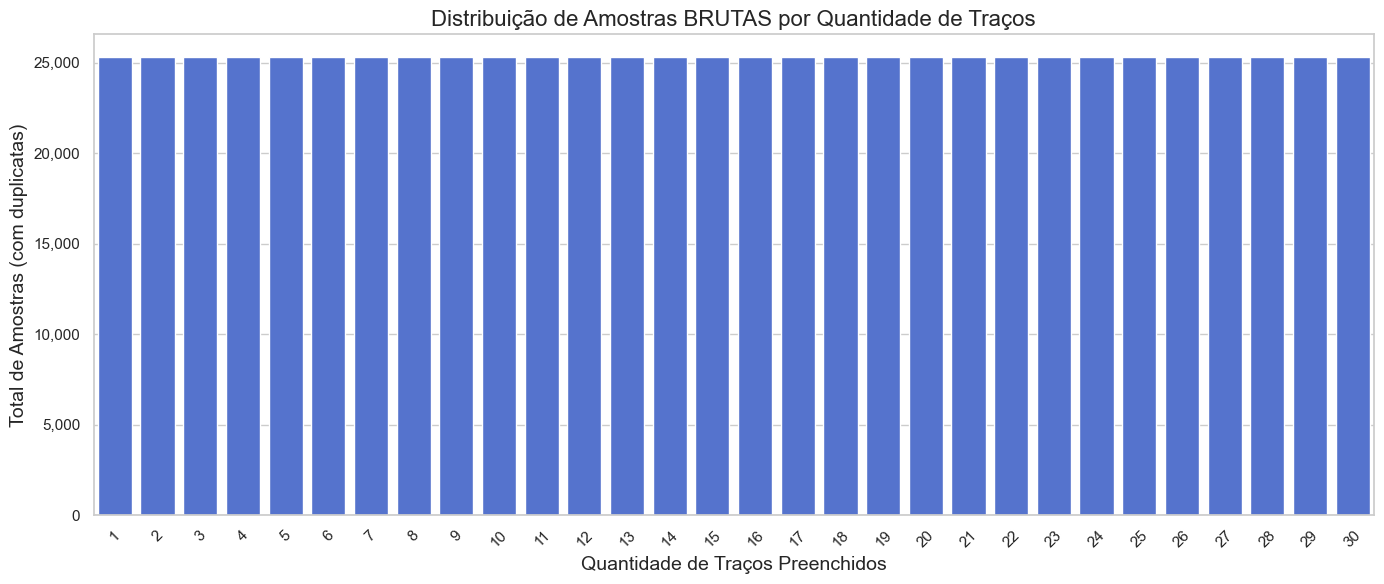

In [4]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_distribuicao, x='Quantidade de Traços', y='Amostras Brutas (Total)', color='royalblue')

plt.title('Distribuição de Amostras BRUTAS por Quantidade de Traços', fontsize=16)
plt.xlabel('Quantidade de Traços Preenchidos', fontsize=14)
plt.ylabel('Total de Amostras (com duplicatas)', fontsize=14)

# Formatar eixo Y com separador de milhar
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Gráfico 2: Matrizes Distintas (Dataset Efetivo da CNN)
Mostra a curva real de aprendizado que será entregue para a CNN treinar, com todas as redundâncias cortadas. Repare que nas extremidades do jogo (como `t=1` ou `t=30`) o número de amostras distintas bate em um teto lógico (saturação do espaço combinatório).

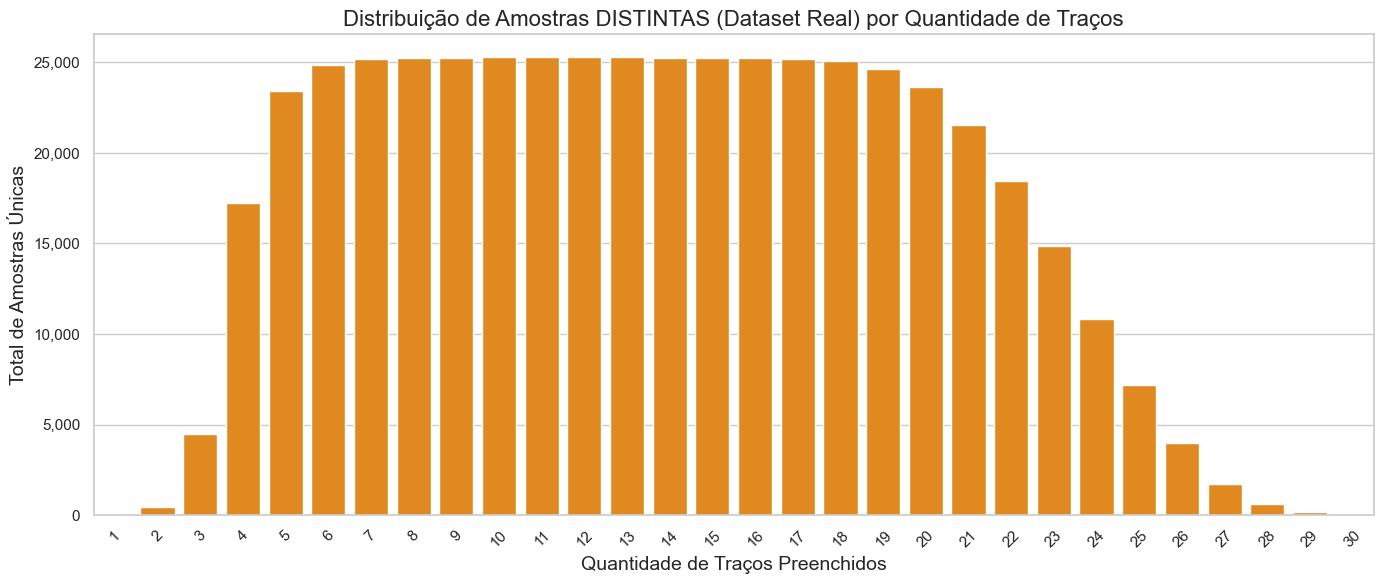

In [5]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_distribuicao, x='Quantidade de Traços', y='Amostras Distintas (Únicas)', color='darkorange')

plt.title('Distribuição de Amostras DISTINTAS (Dataset Real) por Quantidade de Traços', fontsize=16)
plt.xlabel('Quantidade de Traços Preenchidos', fontsize=14)
plt.ylabel('Total de Amostras Únicas', fontsize=14)

# Formatar eixo Y com separador de milhar
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()